In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

from google.colab import drive
drive.mount('/content/drive')
import os
# Change directory to your preferred folder in Drive
%cd /content/drive/MyDrive/IDS 472

telco = pd.read_csv('Telco_Customer_Churn.csv')
telco.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IDS 472


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
telco.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
categorical=['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']
for col in categorical:
    unique_vals = telco[col].unique()
    print(f"Values: {sorted([str(v) for v in unique_vals])}")

Values: ['Female', 'Male']
Values: ['0', '1']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'No phone service', 'Yes']
Values: ['DSL', 'Fiber optic', 'No']
Values: ['No', 'No internet service', 'Yes']
Values: ['No', 'No internet service', 'Yes']
Values: ['No', 'No internet service', 'Yes']
Values: ['No', 'No internet service', 'Yes']
Values: ['No', 'No internet service', 'Yes']
Values: ['No', 'No internet service', 'Yes']
Values: ['Month-to-month', 'One year', 'Two year']
Values: ['No', 'Yes']
Values: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Values: ['No', 'Yes']


In [ ]:
telco.drop(columns=['customerID'], inplace=True) # drop customerID

In [ ]:
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
medianTC= telco['TotalCharges'].median()
telco.TotalCharges = telco.TotalCharges.fillna(value=medianTC)

In [ ]:
categorical=['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']
telco[categorical]=telco[categorical].astype('category') # senior citizen should be catagory too
#

In [ ]:
# change no internet service to no for each additional feature also no phone service
cols_to_replace = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

telco[cols_to_replace] = telco[cols_to_replace].replace('No internet service', 'No')

telco['PhoneService'] = telco['PhoneService'].replace('No phone service', 'No')
telco['MultipleLines'] = telco['MultipleLines'].replace('No phone service', 'No')

/tmp/ipykernel_12903/1600628450.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  telco[cols_to_replace] = telco[cols_to_replace].replace('No internet service', 'No')
/tmp/ipykernel_12903/1600628450.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  telco['MultipleLines'] = telco['MultipleLines'].replace('No phone service', 'No')


In [ ]:
# get values in each again
for col in categorical:
    unique_vals = telco[col].unique()
    print(f"Values: {sorted([str(v) for v in unique_vals])}")


Values: ['Female', 'Male']
Values: ['0', '1']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['DSL', 'Fiber optic', 'No']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['No', 'Yes']
Values: ['Month-to-month', 'One year', 'Two year']
Values: ['No', 'Yes']
Values: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Values: ['No', 'Yes']


In [ ]:
# get proportions of dummies
for col in categorical:
    print(f"\n--- {col} ---")
    print(telco[col].value_counts(normalize=True) * 100)


--- gender ---
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: float64

--- Partner ---
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64

--- Dependents ---
Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64

--- PhoneService ---
PhoneService
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64

--- MultipleLines ---
MultipleLines
No     57.816271
Yes    42.183729
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    43.958540
DSL            34.374556
No             21.666903
Name: proportion, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No     71.333239
Yes    28.666761
Name: proportion, dtype: float64

--- OnlineBackup ---
OnlineBackup
No     65.511856
Yes    34.488144
Name: proportion, dtype: float64

--- DeviceProtection ---
DeviceProtection
No     65.61

26.5% of Response Class is Yes Churn. We should focus on predicting that Minority Class

In [ ]:
telco.columns = [s.strip().replace('_','') for s in telco.columns]

baseline_map = {
    'gender':           'gender_Female',
    'SeniorCitizen':    'SeniorCitizen_0',
    'Partner':          'Partner_No',
    'Dependents':       'Dependents_No',
    'PhoneService':     'PhoneService_No',
    'MultipleLines':    'MultipleLines_No',
    'InternetService':  'InternetService_No',
    'OnlineSecurity':   'OnlineSecurity_No',
    'OnlineBackup':     'OnlineBackup_No',
    'DeviceProtection': 'DeviceProtection_No',
    'TechSupport':      'TechSupport_No',
    'StreamingTV':      'StreamingTV_No',
    'StreamingMovies':  'StreamingMovies_No',
    'Contract':         'Contract_Month-to-month',
    'PaperlessBilling': 'PaperlessBilling_No',
    'PaymentMethod':    'PaymentMethod_Bank transfer (automatic)',
    'Churn': 'Churn_No'
}
telco_dummies = telco.copy()
for col, baseline in baseline_map.items():
  dummies = pd.get_dummies(telco[col], prefix=col)
  dummies = dummies.map(lambda x: int(x))
  dummies = dummies.drop(columns=[baseline])
  telco_dummies = pd.concat([telco_dummies, dummies], axis=1).drop(columns=col)

telco_dummies.rename(columns={'SeniorCitizen_1': 'SeniorCitizen_Yes'}, inplace=True)
telco_dummies.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male',
       'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

In [ ]:
print(telco_dummies.shape) # 7043 observations, 24 features

(7043, 24)


In [ ]:
telco.SeniorCitizen.unique # check all all values
for col in telco_dummies.columns:
    unique_vals = telco_dummies[col].unique()
    print(f"Values {col}: {sorted([str(v) for v in unique_vals])}")

Values tenure: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '8', '9']
Values MonthlyCharges: ['100.0', '100.05', '100.1', '100.15', '100.2', '100.25', '100.3', '100.35', '100.4', '100.45', '100.5', '100.55', '100.6', '100.65', '100.7', '100.75', '100.8', '100.85', '100.9', '100.95', '101.0', '101.05', '101.1', '101.15', '101.25', '101.3', '101.35', '101.4', '101.45', '101.5', '101.55', '101.6', '101.7', '101.75', '101.8', '101.85', '101.9', '101.95', '102.0', '102.05', '102.1', '102.15', '102.25', '102.35', '102.4', '102.45', '102.5', '102.55', '102.6', '102.65', '102.7', '102.8', '102.85', '102.9', '102.95', '103.0', 

Variables, multiple lines to streaming movies have a baseline catagory of 'no' which is different to no internet/phone service

Internet service baseline is DSL,
Contract Baseline is Month to Month,
Payment Method Baseline is bank transfer

In [ ]:
telco_dummies.describe()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_DSL,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928,0.504756,0.162147,0.483033,0.299588,0.903166,0.421837,0.343746,...,0.290217,0.384353,0.387903,0.209144,0.240664,0.592219,0.216101,0.335794,0.228880,0.265370
std,24.559481,30.090047,2265.270398,0.500013,0.368612,0.499748,0.458110,0.295752,0.493888,0.474991,...,0.453895,0.486477,0.487307,0.406726,0.427517,0.491457,0.411613,0.472301,0.420141,0.441561
min,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,402.225000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1397.475000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


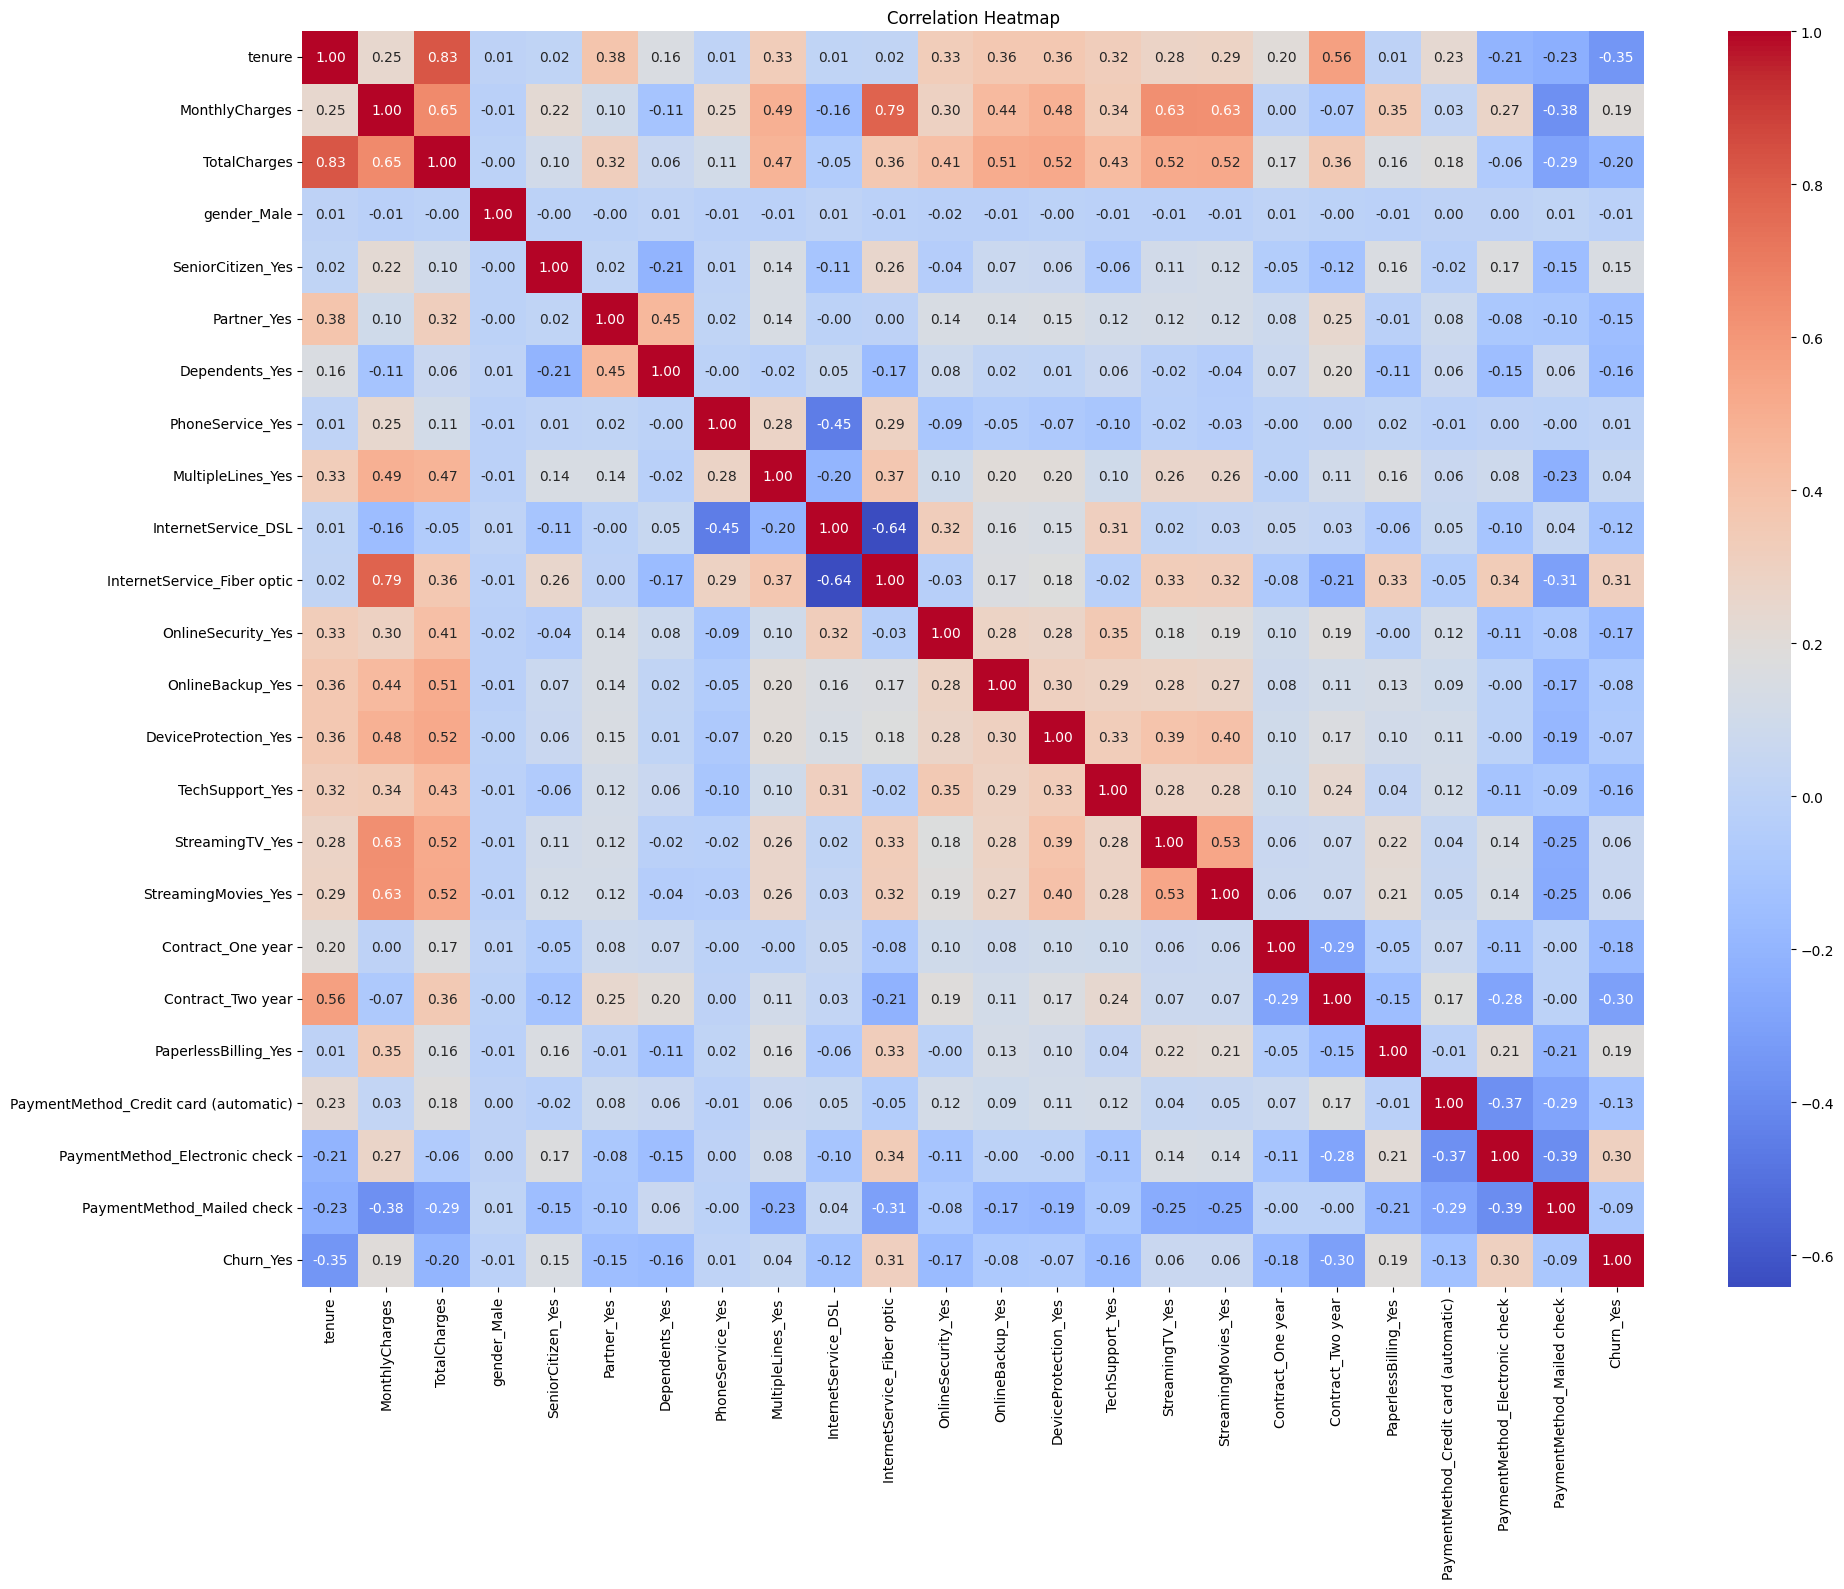

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 16))
sns.heatmap(telco_dummies.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Some High correlations:


*   Total Charges and Tenure
*   Fiber Optic and Monthly Charges
  Monthly charges correlates with a lot of services
  as well as total money
  DSL and Having phone service

Must Fix for Model Interpretability

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame({
    'Feature': telco_dummies.columns,
    'VIF': [variance_inflation_factor(telco_dummies.values, i) for i in range(telco_dummies.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif[vif['VIF']>10])
# gotta get rid of Monthly charges

                        Feature          VIF
1                MonthlyCharges  4872.259267
10  InternetService_Fiber optic  1054.438295
7              PhoneService_Yes   353.846853
9           InternetService_DSL   209.900179
16          StreamingMovies_Yes    39.396300
15              StreamingTV_Yes    39.085052
2                  TotalCharges    17.783837
0                        tenure    15.888071
8             MultipleLines_Yes    12.570621
13         DeviceProtection_Yes    10.550265
12             OnlineBackup_Yes    10.354162


In [ ]:
telco_dummies_full =  telco_dummies.copy()
telco_dummies.drop(columns=['MonthlyCharges'], inplace=True)

vif = pd.DataFrame({
    'Feature': telco_dummies.columns,
    'VIF': [variance_inflation_factor(telco_dummies.values, i) for i in range(telco_dummies.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif[vif['VIF']>10])

        Feature        VIF
1  TotalCharges  17.735069
0        tenure  15.862397


In [ ]:

telco_dummies.drop(columns=['TotalCharges'], inplace=True)

vif = pd.DataFrame({
    'Feature': telco_dummies.columns,
    'VIF': [variance_inflation_factor(telco_dummies.values, i) for i in range(telco_dummies.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif[vif['VIF']>10])

Empty DataFrame
Columns: [Feature, VIF]
Index: []


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

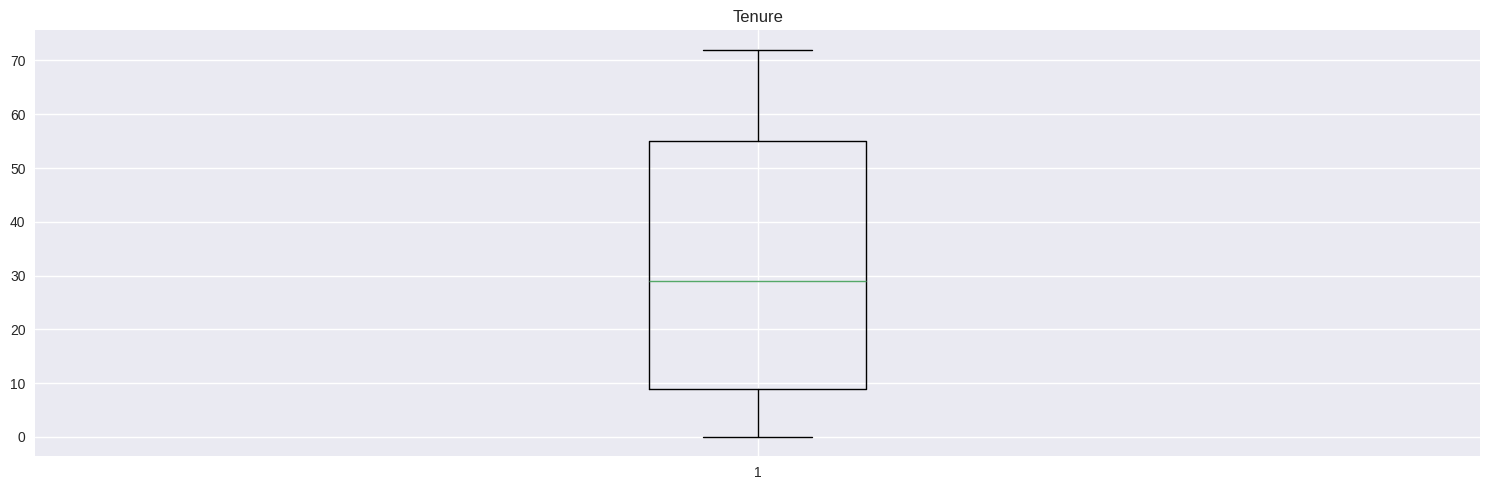

In [ ]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(figsize=(15,5))

axes.boxplot(telco_dummies['tenure'])
axes.set_title('Tenure')

# axes[1].boxplot(telco_dummies['MonthlyCharges'])
# axes[1].set_title('Monthly Charges')

# axes[2].boxplot(telco_dummies['TotalCharges'])
# axes[2].set_title('Total Charges')

plt.tight_layout()

plt.show()

/tmp/ipykernel_12903/3035711913.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_prob = logit(binned.groupby('bin')[predictor].mean()) #find mean of churn by bin, prob of that bin
/tmp/ipykernel_12903/3035711913.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = binned.groupby('bin')[predictor].count() #count amount in each bin


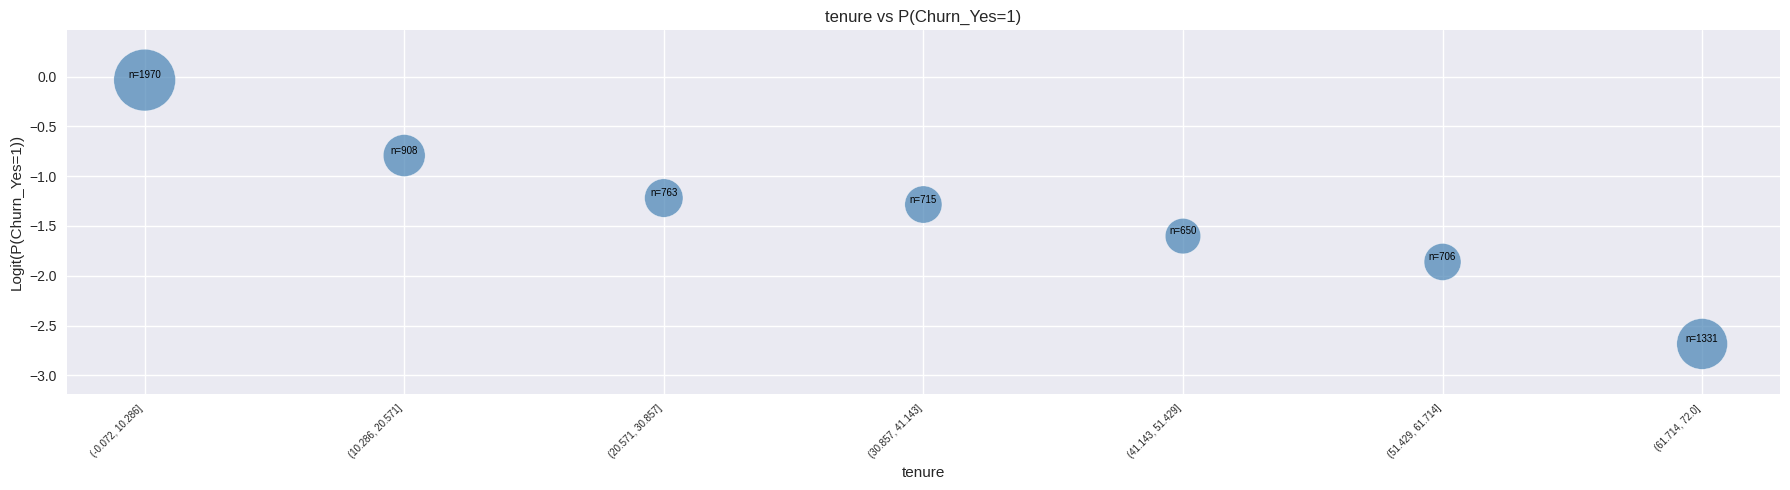

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logit

quantitative = 'tenure'
predictor = 'Churn_Yes'
n_bins = 7

fig, axes = plt.subplots(figsize=(18, 5))


binned = telco_dummies.copy()

binned['bin'] = pd.cut(binned[quantitative], bins=n_bins) #create bin column
bin_prob = logit(binned.groupby('bin')[predictor].mean()) #find mean of churn by bin, prob of that bin
bin_counts = binned.groupby('bin')[predictor].count() #count amount in each bin

scatter = axes.scatter(range(len(bin_prob)), bin_prob.values,
                      s=bin_counts.values, color='steelblue', alpha=0.7, edgecolor='white') # size is shown as size of bin

# Annotate each point with observation count
for i, (prob, count) in enumerate(zip(bin_prob.values, bin_counts.values)):
    axes.text(i, prob + 0.02, f'n={count}', ha='center', fontsize=7, color='black')

axes.set_xticks(range(len(bin_prob)))
axes.set_xticklabels(bin_prob.index.astype(str), rotation=45, ha='right', fontsize=7)
axes.set_title(f'{quantitative} vs P({predictor}=1)')
axes.set_xlabel(quantitative)
axes.set_ylabel(f'Logit(P({predictor}=1))')
axes.set_ylim(bin_prob.min() - 0.5, bin_prob.max() + 0.5)

binned = binned.drop(columns='bin')
plt.tight_layout()
plt.show()

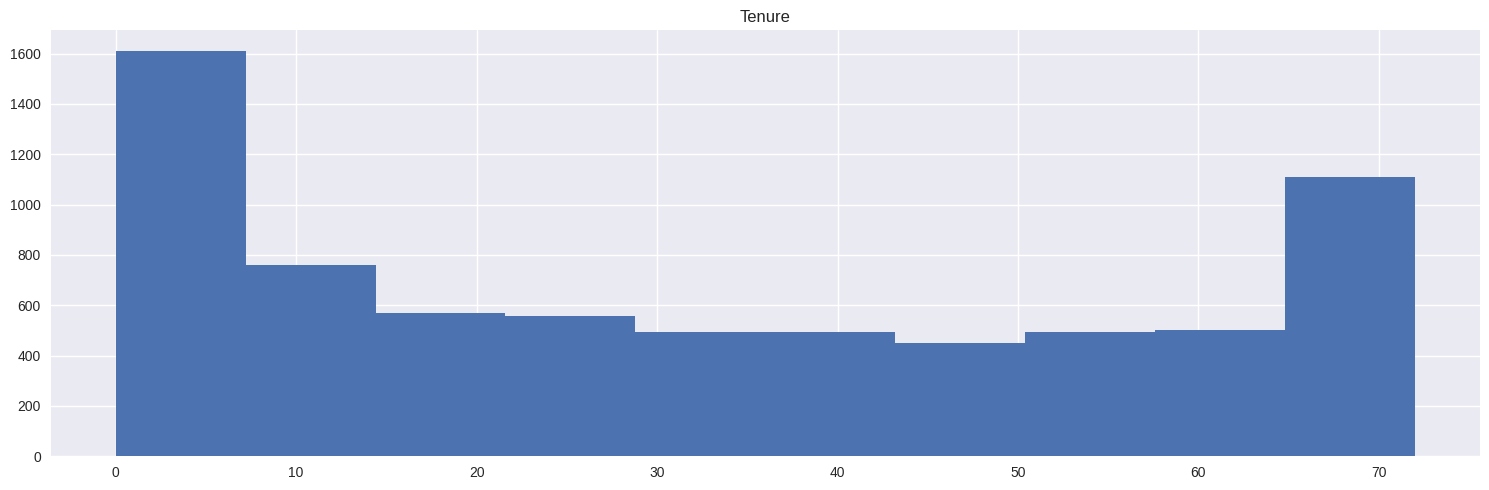

In [ ]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(figsize=(15,5))

axes.hist(telco_dummies['tenure'])
axes.set_title('Tenure')

# axes[1].hist(telco_dummies['MonthlyCharges'])
# axes[1].set_title('Monthly Charges')

# axes[2].hist(telco_dummies['TotalCharges'])
# axes[2].set_title('Total Charges')

plt.tight_layout()

plt.show()

In [ ]:
#Exclude monthly charges

In [ ]:
excludeColumns = ('Churn_Yes')

outcome='Churn_Yes'
predictors=[s for s in telco_dummies.columns if s not in excludeColumns]

X=telco_dummies[predictors]
Y=telco_dummies[outcome]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2, random_state=1)

In [ ]:
print("Training Data Set:")
print('X_train:',X_train.shape)
print('Y_train:',Y_train.shape)
print('Test Data Set:')
print('X_test:',X_test.shape)
print('Y_test:',Y_test.shape)

Training Data Set:
X_train: (5634, 21)
Y_train: (5634,)
Test Data Set:
X_test: (1409, 21)
Y_test: (1409,)


Contending Models For Interpretability and handling Categorical Variables:
 Logistic Regression - Variables Might not be 'Linear' interpreting Multilinear coefficients can be a problem
 CART Tree -

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

param_grid = [
    {     'C':          [0.01, 0.1, 1, 10],
        'penalty':      ['l1'],
          'class_weight':     [None, 'balanced', {0: 1, 1: 3.77}],
        'solver':       ['saga', 'liblinear']
    },
    {
        'C':            [0.01, 0.1, 1, 10],
        'penalty':      ['l2'],
        'class_weight':     [None, 'balanced', {0: 1, 1: 3.77}],
        'solver':       ['liblinear','lbfgs']
    },
    {
        'C':            [0.01, 0.1, 1, 10],
        'penalty':      ['elasticnet'],
        'class_weight':     [None, 'balanced', {0: 1, 1: 3.77}],
        'solver':       ['saga'],
        'l1_ratio':     [0.2, 0.5, 0.8],
    }
]

LogGSCV = GridSearchCV(
    estimator=LogisticRegression(max_iter = 500), # adjust for 26.5% positive class
    param_grid=param_grid,
    scoring='f1', # want to predict the positive class well
    cv=cv,
    n_jobs=-1,
    verbose=1
)

LogGSCV.fit(X_train, Y_train)

print(f"Best Recall Score: {LogGSCV.best_score_:.4f}")
print(f"Best Parameters:   {LogGSCV.best_params_}")

best_model = LogGSCV.best_estimator_


Fitting 4 folds for each of 84 candidates, totalling 336 fits
Best Recall Score: 0.6302
Best Parameters:   {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.2, 'penalty': 'elasticnet', 'solver': 'saga'}


In [ ]:
results = pd.DataFrame(LogGSCV.cv_results_)
results.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_penalty,param_solver,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
60,2.428050,0.452724,0.010274,0.003759,0.10,balanced,elasticnet,saga,0.2,"{'C': 0.1, 'class_weight': 'balanced', 'l1_rat...",0.641469,0.635121,0.621053,0.623085,0.630182,0.008448,1
33,0.180041,0.018643,0.012854,0.001808,0.10,balanced,l2,lbfgs,NaN,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.641387,0.636364,0.623158,0.619632,0.630135,0.009005,2
32,0.040416,0.010553,0.013000,0.004097,0.10,balanced,l2,liblinear,NaN,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.641387,0.635692,0.623158,0.619632,0.629967,0.008893,3
39,0.150353,0.052358,0.010760,0.003789,1.00,balanced,l2,lbfgs,NaN,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",0.641026,0.631250,0.625793,0.620408,0.629619,0.007620,4
38,0.051089,0.003051,0.017504,0.003740,1.00,balanced,l2,liblinear,NaN,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",0.641026,0.630593,0.625793,0.620408,0.629455,0.007590,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,1.068386,0.210182,0.006341,0.000283,0.01,None,elasticnet,saga,0.2,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.512648,0.565625,0.552716,0.526316,0.539326,0.020928,80
49,0.716933,0.095930,0.006157,0.000195,0.01,None,elasticnet,saga,0.5,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.500000,0.551053,0.512479,0.501650,0.516296,0.020632,81
1,0.046614,0.007458,0.027231,0.002997,0.01,None,l1,liblinear,NaN,"{'C': 0.01, 'class_weight': None, 'penalty': '...",0.500000,0.534622,0.519737,0.485342,0.509925,0.018768,82
50,0.525863,0.031029,0.005953,0.000147,0.01,None,elasticnet,saga,0.8,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.484536,0.537068,0.520000,0.480801,0.505601,0.023750,83


In [ ]:
from sklearn.metrics import recall_score
y_pred = best_model.predict(X_test)
recall = recall_score(Y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.8333


In [ ]:
logCoef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0]
})
logCoef.reindex(logCoef['Coefficient'].abs().sort_values(ascending=False).index)

,Feature,Coefficient
8,InternetService_Fiber optic,1.479409
16,Contract_Two year,-1.262279
15,Contract_One year,-0.594822
7,InternetService_DSL,0.578204
14,StreamingMovies_Yes,0.344802
19,PaymentMethod_Electronic check,0.330287
5,PhoneService_Yes,-0.326542
17,PaperlessBilling_Yes,0.322948
9,OnlineSecurity_Yes,-0.270386
6,MultipleLines_Yes,0.254629


In [ ]:
excludeColumns = ('Churn_Yes')

outcome='Churn_Yes'
predictors=[s for s in telco_dummies_full.columns if s not in excludeColumns]

X=telco_dummies_full[predictors]
Y=telco_dummies_full[outcome]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2, random_state=30)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight':     [None, 'balanced', {0: 1, 1: 3.77}],
    'ccp_alpha':        [0.0, 0.001, 0.01, 0.1]
}

TreeGSCV = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

TreeGSCV.fit(X_train, Y_train)

print(f"Best F1 Score: {TreeGSCV.best_score_:.4f}")
print(f"Best Parameters:   {TreeGSCV.best_params_}")

best_tree = TreeGSCV.best_estimator_

# Evaluate on test set
y_pred_tree = best_tree.predict(X_test)
print(recall_score(Y_test, y_pred_tree))
print(accuracy_score(Y_test, y_pred_tree))

Fitting 3 folds for each of 960 candidates, totalling 2880 fits
Best F1 Score: 0.6184
Best Parameters:   {'ccp_alpha': 0.01, 'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.7573529411764706
0.7444996451383961


In [ ]:
results = pd.DataFrame(TreeGSCV.cv_results_)
results.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_class_weight,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
704,0.086333,0.005291,0.013507,0.001607,0.01,"{0: 1, 1: 3.77}",None,1,2,"{'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: ...",0.633094,0.61551,0.606532,0.618379,0.011032,1
705,0.076563,0.016597,0.013033,0.004732,0.01,"{0: 1, 1: 3.77}",None,1,5,"{'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: ...",0.633094,0.61551,0.606532,0.618379,0.011032,1
706,0.055783,0.004241,0.014104,0.005422,0.01,"{0: 1, 1: 3.77}",None,1,10,"{'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: ...",0.633094,0.61551,0.606532,0.618379,0.011032,1
707,0.048993,0.011103,0.008493,0.003137,0.01,"{0: 1, 1: 3.77}",None,1,20,"{'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: ...",0.633094,0.61551,0.606532,0.618379,0.011032,1
708,0.076935,0.026121,0.008847,0.003239,0.01,"{0: 1, 1: 3.77}",None,2,2,"{'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: ...",0.633094,0.61551,0.606532,0.618379,0.011032,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,0.035700,0.006441,0.016346,0.003894,0.10,None,3,2,20,"{'ccp_alpha': 0.1, 'class_weight': None, 'max_...",0.000000,0.00000,0.000000,0.000000,0.000000,801
726,0.024985,0.008069,0.014751,0.001678,0.10,None,3,2,10,"{'ccp_alpha': 0.1, 'class_weight': None, 'max_...",0.000000,0.00000,0.000000,0.000000,0.000000,801
725,0.013620,0.000118,0.006259,0.000021,0.10,None,3,2,5,"{'ccp_alpha': 0.1, 'class_weight': None, 'max_...",0.000000,0.00000,0.000000,0.000000,0.000000,801
724,0.031835,0.001577,0.011937,0.004587,0.10,None,3,2,2,"{'ccp_alpha': 0.1, 'class_weight': None, 'max_...",0.000000,0.00000,0.000000,0.000000,0.000000,801


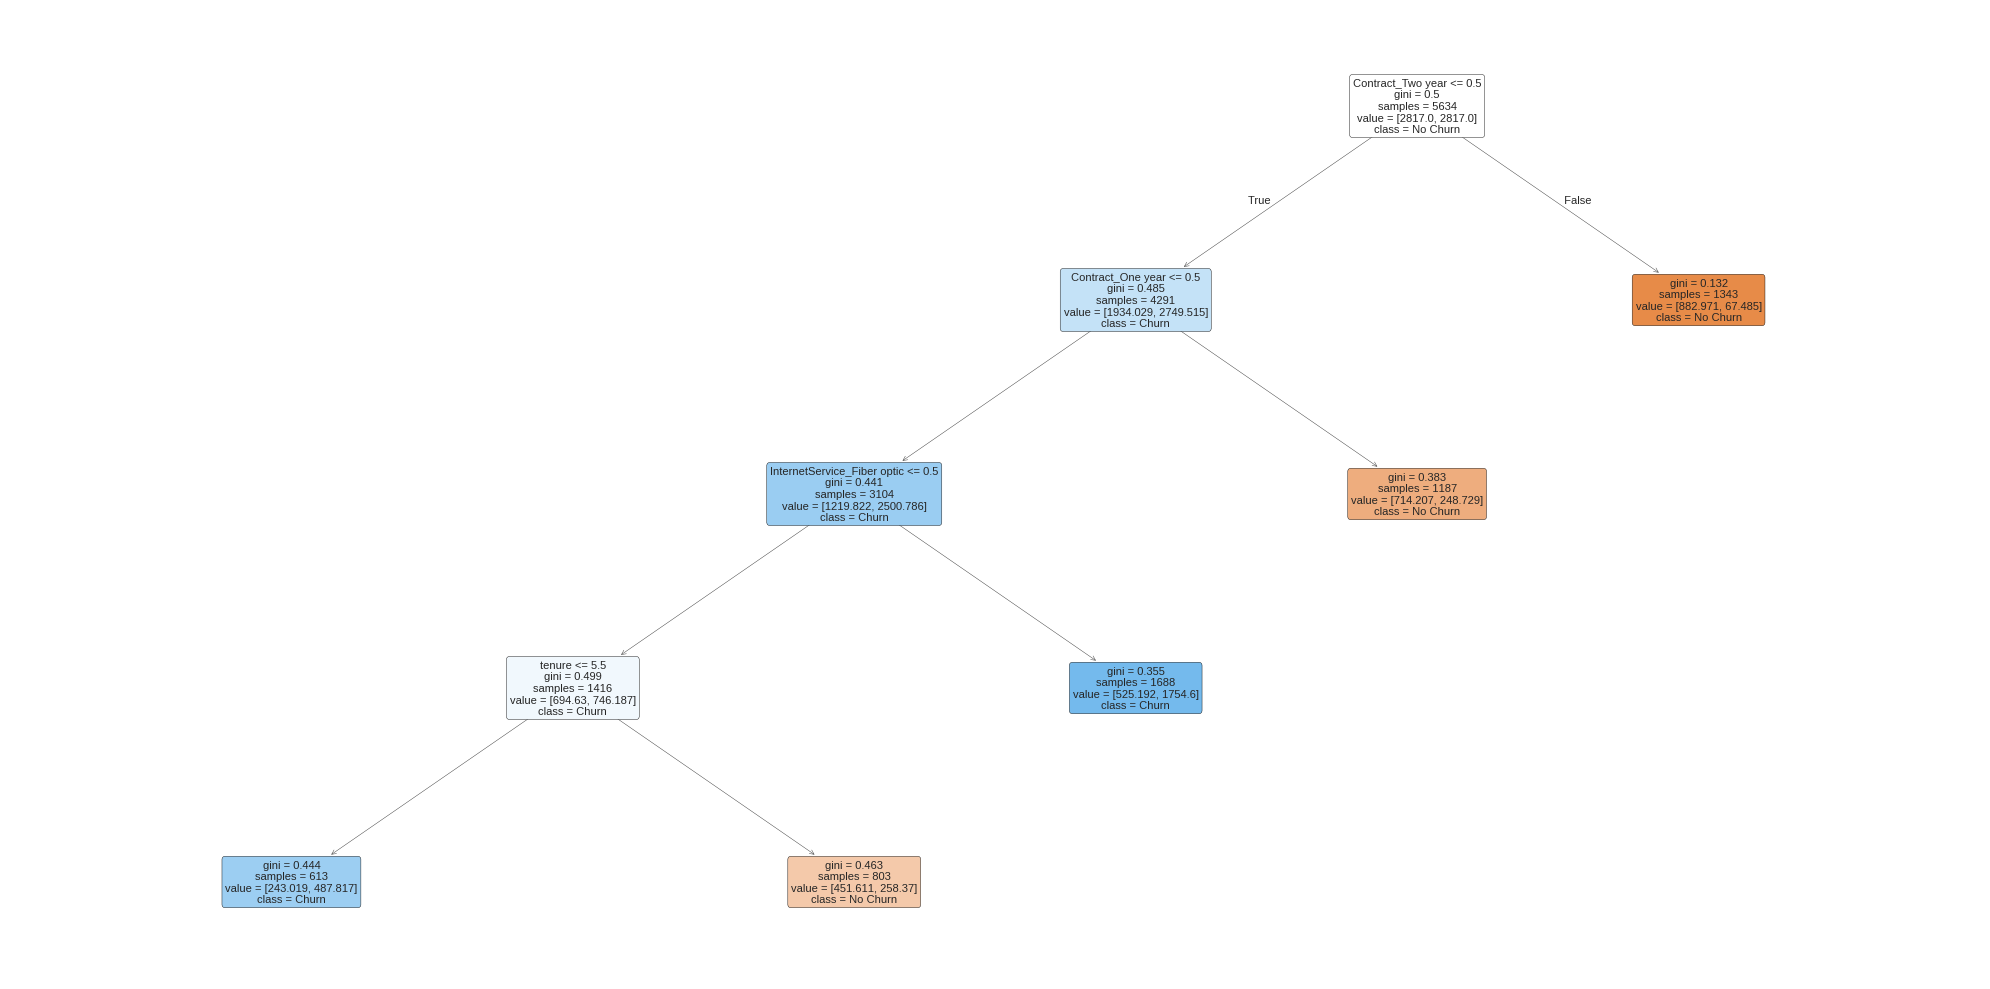

In [ ]:
from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(best_tree,
          feature_names=X_train.columns.tolist(),
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=8,
          ax=ax)

plt.tight_layout()
plt.show()

Part 3 Model Building and Evaluation

In [ ]:
# import appropriate methods for Random Tree Classifier and Gradient Boosting Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

#import metrics Accuracy, Precision, Recall, F1-Score, ROC-AUC curve, Confusion matrix
from sklearn.metrics import (accuracy_score,
                             recall_score, precision_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)

# import appropriate libraries for graphs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [ ]:
#storing target column Churn_Yes as variable for reference
excludeColumns = ('Churn_Yes')

# repeat Logistic Regression split to avoid overwriting previous split
target ='Churn_Yes'
predictors_log=[s for s in telco_dummies.columns if s not in excludeColumns]

X_log = telco_dummies[predictors_log]
Y_log = telco_dummies[outcome]

X_train_log, X_test_log, Y_train_log, Y_test_log = train_test_split(
    X_log, Y_log, test_size=0.2, random_state=1
)

In [ ]:
# Build Random Forest Model
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Defining metrics to build model, like # of tree estimators, max depth,etc.
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10,20, None],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced', {0: 1, 1: 3.77}]
}

# Applying GridSearchCV to test every combo in rf_param_grid w/ cross validation
#
RfGSCV = GridSearchCV(
    estimator=RandomForestClassifier(random_state = 42),
    param_grid=rf_param_grid,
    scoring='f1', # pick best combo based on f1 score
    cv=cv, # use StratifiesKFold splits
    n_jobs=-1,# uses more CPU core for faster running
    verbose=1 # prints progress updates while model runs
)
# Training
RfGSCV.fit(X_train, Y_train)

#print results for best f1 score and parameter combo
print(f'Best F1 Score(CV): {RfGSCV.best_score_:.4f}')
print(f'Best Parameters: {RfGSCV.best_params_:}')

#store best model for later predictions and evals
best_rf = RfGSCV.best_estimator_

Fitting 4 folds for each of 108 candidates, totalling 432 fits
Best F1 Score(CV): 0.6333
Best Parameters: {'class_weight': {0: 1, 1: 3.77}, 'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 300}


In [ ]:
# Build Gradient Boosting Model
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Defining metrics to build model, like # of tree estimators, max depth,etc.
gb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Applying GridSearchCV to test every combo in gb_param_grid w/ cross validation
GbGSCV = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state = 42),
    param_grid=gb_param_grid,
    scoring='f1', # pick best combo based on f1 score
    cv=cv, # use StratifiesKFold splits
    n_jobs=-1,# uses more CPU core for faster running
    verbose=1 # prints progress updates while model runs
)
# Training
GbGSCV.fit(X_train, Y_train)

Fitting 4 folds for each of 36 candidates, totalling 144 fits


GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [ ]:
#print results for best f1 score and parameter combo
print(f'Best F1 Score(CV): {GbGSCV.best_score_:.4f}')
print(f'Best Parameters: {GbGSCV.best_params_:}')

#store best model for later predictions and evals
best_gb = GbGSCV.best_estimator_

Best F1 Score(CV): 0.5812
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [ ]:
#print metrics Accuracy, Precision, Recall, F1-Score, ROC-AUC curve, Confusion matrix

# Logistic Regression
y_pred_log = best_model.predict(X_test_log)
Y_prob_log = best_model.predict_proba(X_test_log)[:, 1]

print("Accuracy = {:.3f}".format(accuracy_score(Y_test_log, y_pred_log)))
print('--'*20)

print("Precision = {:.3f}".format(precision_score(Y_test_log, y_pred_log)))
print('--'*20)

print("Recall = {:.3f}".format(recall_score(Y_test_log, y_pred_log)))
print('--'*20)

print("F1 score = {:.3f}".format(f1_score(Y_test_log, y_pred_log)))
print('--'*20)

print("ROC AUC = {:.3f}".format(roc_auc_score(Y_test_log, Y_prob_log)))
print('--'*20)

Accuracy = 0.759
----------------------------------------
Precision = 0.507
----------------------------------------
Recall = 0.833
----------------------------------------
F1 score = 0.630
----------------------------------------
ROC AUC = 0.856
----------------------------------------


In [ ]:
#print metrics Accuracy, Precision, Recall, F1-Score, ROC-AUC curve, Confusion matrix

# Decision Tree
y_pred_tree = best_tree.predict(X_test)
Y_prob_tree = best_tree.predict_proba(X_test)[:, 1]

print("Accuracy = {:.3f}".format(accuracy_score(Y_test, y_pred_tree)))
print('--'*20)

print("Precision = {:.3f}".format(precision_score(Y_test, y_pred_tree)))
print('--'*20)

print("Recall = {:.3f}".format(recall_score(Y_test, y_pred_tree)))
print('--'*20)

print("F1 score = {:.3f}".format(f1_score(Y_test, y_pred_tree)))
print('--'*20)

print("ROC AUC = {:.3f}".format(roc_auc_score(Y_test, Y_prob_tree)))
print('--'*20)


Accuracy = 0.744
----------------------------------------
Precision = 0.542
----------------------------------------
Recall = 0.757
----------------------------------------
F1 score = 0.632
----------------------------------------
ROC AUC = 0.795
----------------------------------------


In [ ]:
#print metrics Accuracy, Precision, Recall, F1-Score, ROC-AUC curve, Confusion matrix

# Random Forest
y_pred_rf = best_rf.predict(X_test)
Y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy = {:.3f}".format(accuracy_score(Y_test, y_pred_rf)))
print('--'*20)

print("Precision = {:.3f}".format(precision_score(Y_test, y_pred_rf)))
print('--'*20)

print("Recall = {:.3f}".format(recall_score(Y_test, y_pred_rf)))
print('--'*20)

print("F1 score = {:.3f}".format(f1_score(Y_test, y_pred_rf)))
print('--'*20)

print("ROC AUC = {:.3f}".format(roc_auc_score(Y_test, Y_prob_rf)))
print('--'*20)


Accuracy = 0.757
----------------------------------------
Precision = 0.562
----------------------------------------
Recall = 0.735
----------------------------------------
F1 score = 0.637
----------------------------------------
ROC AUC = 0.839
----------------------------------------


In [ ]:
#print metrics Accuracy, Precision, Recall, F1-Score, ROC-AUC curve, Confusion matrix

# Gradient Boosting
y_pred_gb = best_gb.predict(X_test)
Y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

print("Accuracy = {:.3f}".format(accuracy_score(Y_test, y_pred_gb)))
print('--'*20)

print("Precision = {:.3f}".format(precision_score(Y_test, y_pred_gb)))
print('--'*20)

print("Recall = {:.3f}".format(recall_score(Y_test, y_pred_gb)))
print('--'*20)

print("F1 score = {:.3f}".format(f1_score(Y_test, y_pred_gb)))
print('--'*20)

print("ROC AUC = {:.3f}".format(roc_auc_score(Y_test, Y_prob_gb)))
print('--'*20)

Accuracy = 0.784
----------------------------------------
Precision = 0.677
----------------------------------------
Recall = 0.488
----------------------------------------
F1 score = 0.567
----------------------------------------
ROC AUC = 0.833
----------------------------------------


In [ ]:
# Confusion Matrices

# Logistic Regression
cm_log = confusion_matrix(Y_test_log, y_pred_log)
print("Logistic Regression Confusion Matrix:")
print(cm_log)

Logistic Regression Confusion Matrix:
[[779 282]
 [ 58 290]]


In [ ]:
# Confusion Matrices

# Decision Tree Classifier
cm_tree = confusion_matrix(Y_test, y_pred_tree)
print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[740 261]
 [ 99 309]]


In [ ]:
# Confusion Matrices

# Random Forest
cm_rf = confusion_matrix(Y_test, y_pred_rf)
print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[767 234]
 [108 300]]


In [ ]:
# Confusion Matrices

# Gradient Boosting
cm_gb = confusion_matrix(Y_test, y_pred_gb)
print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

Gradient Boosting Confusion Matrix:
[[906  95]
 [209 199]]


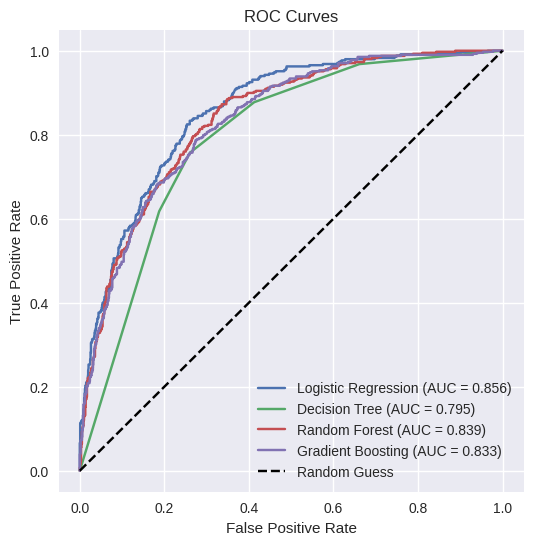

In [ ]:
# ROC curves all on 1 plot

plt.figure(figsize=(6, 6))

#Logistic Regression
fpr_log, tpr_log,_ = roc_curve(Y_test_log, Y_prob_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(Y_test_log, Y_prob_log):.3f})')

# Decision Tree Classifier
fpr_tree, tpr_tree,_ = roc_curve(Y_test, Y_prob_tree)
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_score(Y_test, Y_prob_tree):.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(Y_test, Y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(Y_test, Y_prob_rf):.3f})')

#Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(Y_test, Y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(Y_test, Y_prob_gb):.3f})')

# for cleaner, readable plot
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# repeat feature importance for new models Random Forest and Gradient Boosting
#create a dataset for comparing features with their importance

Importance_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': best_rf.feature_importances_}).sort_values('Importance', ascending=False)

Importance_rf

,Feature,Importance
0,tenure,0.166103
2,TotalCharges,0.144857
1,MonthlyCharges,0.131102
18,Contract_Two year,0.119047
10,InternetService_Fiber optic,0.089143
21,PaymentMethod_Electronic check,0.060643
17,Contract_One year,0.045273
11,OnlineSecurity_Yes,0.027363
19,PaperlessBilling_Yes,0.023194
9,InternetService_DSL,0.022849


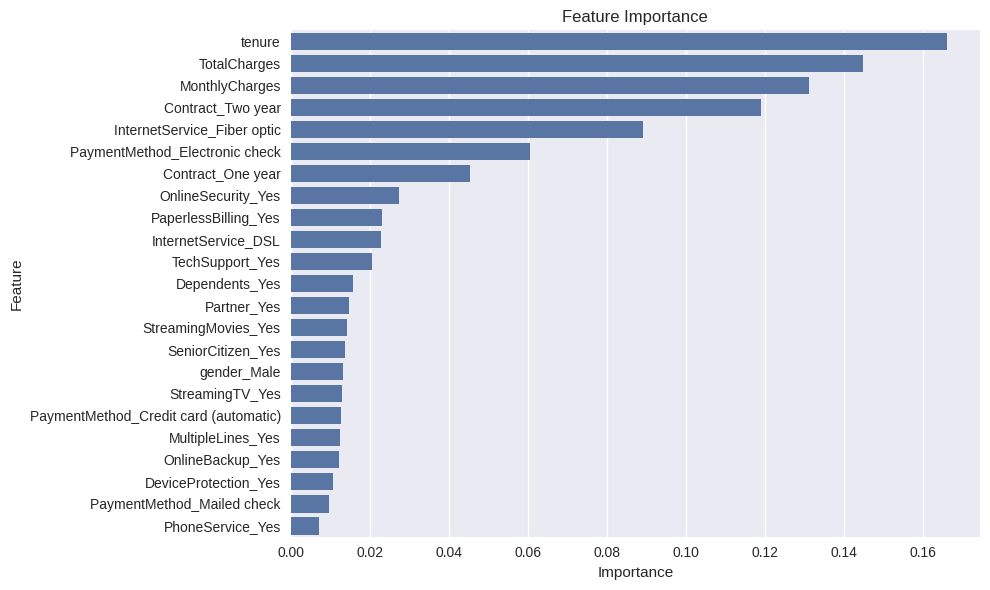

In [ ]:
# Make Random Forest feature importance plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=Importance_rf)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
#create a dataset for comparing features with their importance
Importance_gb = pd.DataFrame({'Feature': X_train.columns, 'Importance': best_gb.feature_importances_}).sort_values('Importance', ascending=False)

Importance_gb

,Feature,Importance
0,tenure,0.266418
10,InternetService_Fiber optic,0.174170
2,TotalCharges,0.120830
21,PaymentMethod_Electronic check,0.118641
1,MonthlyCharges,0.107131
18,Contract_Two year,0.062583
17,Contract_One year,0.047690
11,OnlineSecurity_Yes,0.022936
19,PaperlessBilling_Yes,0.015171
4,SeniorCitizen_Yes,0.012789


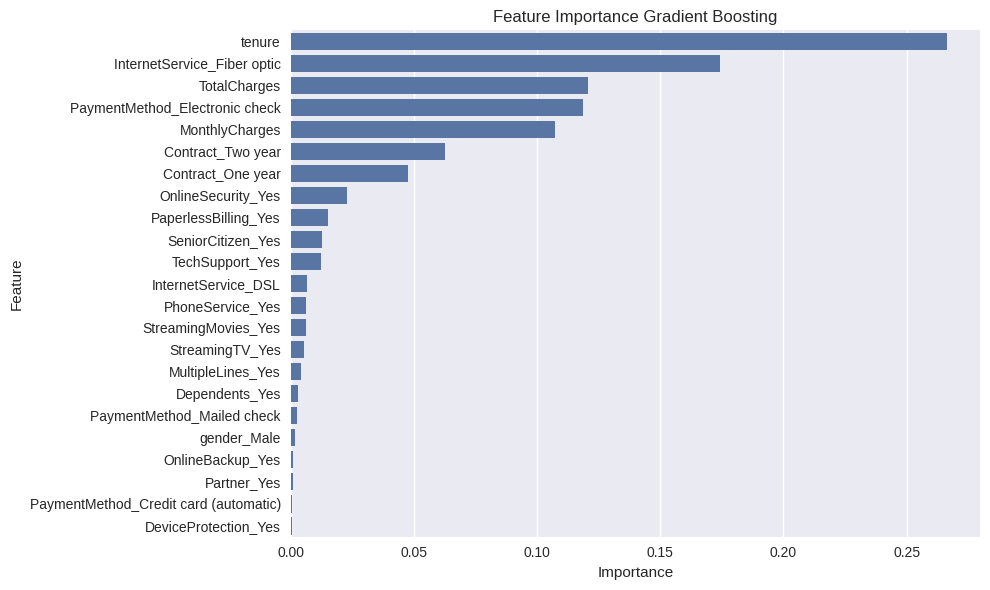

In [ ]:
# Make Gradient Boosting feature importance plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=Importance_gb)
plt.title('Feature Importance Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()